<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Multi-Crop-Ranking/Multi_Crop_Ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import libraries**

In [31]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit


**Load Data**

In [32]:
try:
    crop_req = pd.read_csv("/content/drive/MyDrive/DSGP/Crop_training_data_full.csv")
    print("Dataset loaded correctly")
    print(crop_req.shape)

except Exception as e:
    print("Dataset loading failed:", e)

crop_req.head()

Dataset loaded correctly
(2100, 18)


,crop,temperature,rainfall,ph,organic_carbon,cec,awc,bulk_density,texture,texture_num,texture_tolerance,texture_tol_num,rooting_depth,root_depth_num,sun_req,sun_req_num,suitability_score,suitability_class
0,Banana,24.218789,1514.490115,8.139456,1.487176,35.074121,0.321336,1.452704,Clayey loam,4,High,3,Deep,4,High,3,0.949,Suitable
1,Mangosteen,27.241423,1927.666758,5.172037,3.984712,16.122542,0.284810,0.982135,Heavy clay,5,High,3,Medium,2,Medium,2,0.914,Suitable
2,Okra,22.506573,983.720536,7.669090,3.914564,9.949383,0.333349,1.628292,Sandy loam,2,Medium,2,Medium,2,High,3,0.678,Unsuitable
3,Luffa,37.964878,2466.376956,7.990884,1.828160,29.958186,0.095352,1.542933,Loam,3,High,3,Shallow,1,High,3,0.692,Unsuitable
4,Sweet Potato,21.852794,1482.314049,6.965394,2.453519,12.637792,0.390210,1.212753,Clayey loam,4,High,3,Shallow,1,High,3,0.655,Unsuitable


**Convert Suitability Score To Ranking Label**

In [33]:
def to_rank(score):
    if score >= 0.8:
        return 3
    elif score >= 0.6:
        return 2
    elif score >= 0.4:
        return 1
    else:
        return 0

crop_req["rank_label"] = crop_req["suitability_score"].apply(to_rank)
crop_req['scenario_id'] = np.arange(len(crop_req)) // 21

**Define Features**

In [34]:
FEATURES = [
    "temperature",
    "rainfall",
    "ph",
    "organic_carbon",
    "cec",
    "awc",
    "bulk_density"
]

# Split Data into Training and Testing
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(crop_req, groups=crop_req['scenario_id']))

train_df = crop_req.iloc[train_idx].copy()
test_df = crop_req.iloc[test_idx].copy()

# Prepare X and y for Train and Test
X_train = train_df[FEATURES]
y_train = train_df["rank_label"]
X_test = test_df[FEATURES]
y_test = test_df["rank_label"]

# Define Query Groups for LightGBM
groups_train = train_df.groupby('scenario_id').size().tolist()
groups_test = test_df.groupby('scenario_id').size().tolist()

**Create LightGBM Dataset**

In [35]:
train_data = lgb.Dataset(X_train, label=y_train, group=groups_train)
### NEW: Added a separate test dataset for accuracy validation
test_data = lgb.Dataset(X_test, label=y_test, group=groups_test, reference=train_data)

**LambdaMART Parameters**

In [36]:
params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [1, 3, 5],
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 20,
    "verbosity": -1
}

**Train Model**

In [23]:
#Prevent the overfitting
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    valid_names=['Training', 'Validation'],
    num_boost_round=500,
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[9]	Training's ndcg@1: 0.992857	Training's ndcg@3: 0.945044	Training's ndcg@5: 0.888247	Validation's ndcg@1: 0.714286	Validation's ndcg@3: 0.680607	Validation's ndcg@5: 0.682353


**Rank Crops**

In [24]:
crop_req["rank_score"] = model.predict(X)

ranked = crop_req.sort_values("rank_score", ascending=False)
ranked[["crop", "rank_score"]].head(5)

,crop,rank_score
1968,Luffa,0.572469
1532,Kiriala,0.572469
701,Snake Gourd,0.572469
1751,Kiriala,0.570509
1172,Banana,0.566286


**Predictions & Accuracy Check**

In [25]:
### NEW: Predict on the unseen test data to verify real-world accuracy
test_df["rank_score"] = model.predict(X_test)

# Display Top 5 ranked crops for a specific scenario in the test set
print("\n--- Sample Ranking for an Unseen Scenario ---")
sample_scenario = test_df[test_df['scenario_id'] == test_df['scenario_id'].iloc[0]]
ranked_sample = sample_scenario.sort_values("rank_score", ascending=False)
print(ranked_sample[["crop", "rank_score", "suitability_score"]].head(5))


--- Sample Ranking for an Unseen Scenario ---
             crop  rank_score  suitability_score
1      Mangosteen    0.486122              0.914
6  Yard Long Bean    0.367465              0.723
4    Sweet Potato    0.253264              0.655
8        Turmeric    0.167385              0.809
2            Okra    0.034373              0.678


**Suitability Score Histogram**

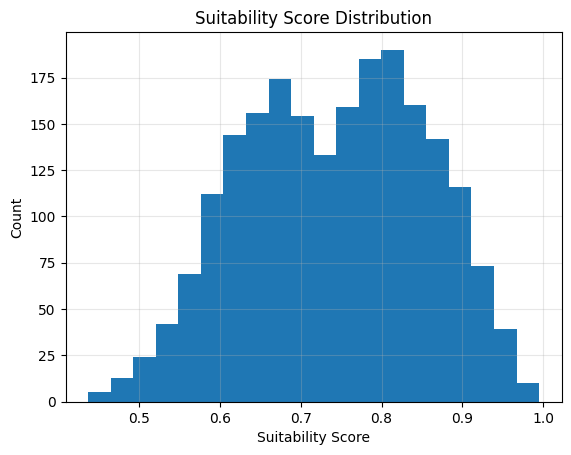

In [26]:
plt.figure()
plt.hist(crop_req["suitability_score"], bins=20)
plt.title("Suitability Score Distribution")
plt.xlabel("Suitability Score")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()


**Feature Importance Plot**

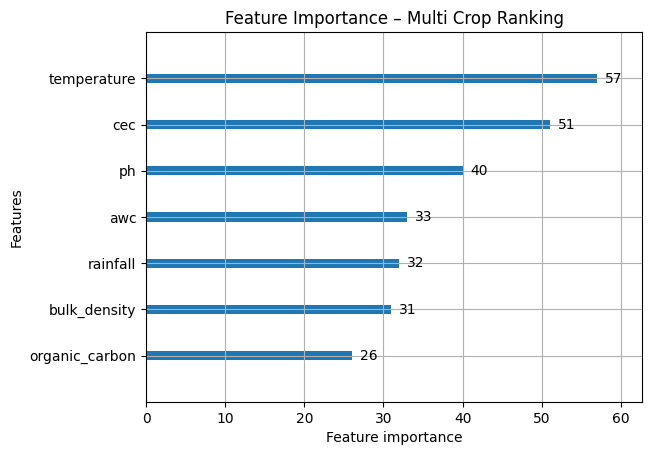

In [27]:
lgb.plot_importance(model, max_num_features=10)
plt.title("Feature Importance – Multi Crop Ranking")
plt.show()


**Correlation Heatmap**

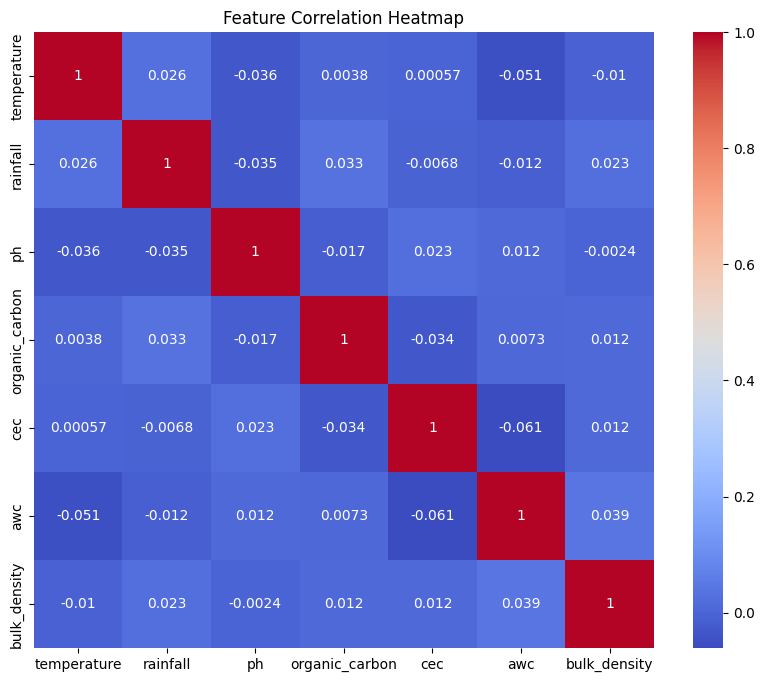

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(crop_req[FEATURES].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

**Suitability Score Histogram**

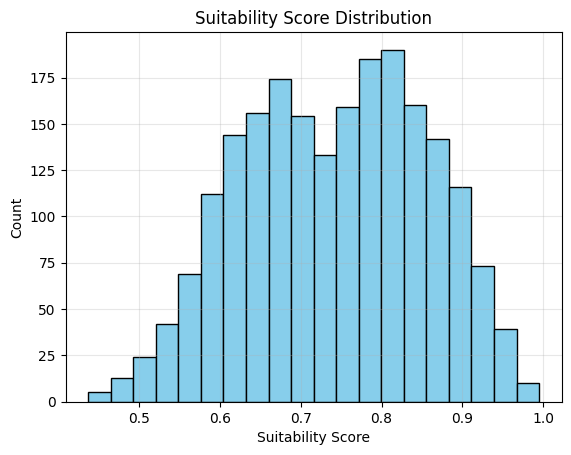

In [30]:
plt.figure()
plt.hist(crop_req["suitability_score"], bins=20, color='skyblue', edgecolor='black')
plt.title("Suitability Score Distribution")
plt.xlabel("Suitability Score")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()